In [2]:
import pandas as pd

In [3]:
trd=pd.read_pickle('adult_train_clean.pkl')

In [4]:
tsd=pd.read_pickle('adult_test_clean.pkl')

In [5]:
X_train=trd.drop('salary', axis=1)
y_train=trd['salary']
X_test=tsd.drop('salary',axis=1)
y_test=tsd['salary']

In [6]:
hcols=['workclass', 'martial-status', 'occupation', 'relationship', 'race', 'native-country']

In [7]:
X_train=pd.get_dummies(
    X_train,
    columns=hcols,
    drop_first=True
)

In [8]:
X_test=pd.get_dummies(
    X_test,
    columns=hcols,
    drop_first=True
)

In [9]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [10]:
scols=['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train[scols]=scaler.fit_transform(X_train[scols])
X_test[scols]=scaler.transform(X_test[scols])

In [12]:
X_test.head()

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
1,-1.023104,0.350286,-1.224066,0,-0.147445,-0.218586,-0.077734,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.033340,-0.946320,-0.439738,0,-0.147445,-0.218586,0.757005,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,-0.794697,1.392858,0.736754,0,-0.147445,-0.218586,-0.077734,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,0.423474,-0.278945,-0.047574,0,0.890601,-0.218586,-0.077734,False,True,False,...,False,False,False,False,False,False,False,True,False,False
6,-0.337883,0.084232,-1.616231,0,-0.147445,-0.218586,-0.912474,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [13]:
X_train.head()

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.042796,-1.062722,1.128918,0,0.146092,-0.218586,-0.077734,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.880288,-1.007871,1.128918,0,-0.147445,-0.218586,-2.331531,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.033340,0.244693,-0.439738,0,-0.147445,-0.218586,-0.077734,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,1.108695,0.425240,-1.224066,0,-0.147445,-0.218586,-0.077734,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,-0.794697,1.406658,1.128918,1,-0.147445,-0.218586,-0.077734,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
import matplotlib.pyplot as plt

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

k_values=range(1,31)
accuracies=[]

for k in k_values:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred=knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(f"Completed for k={k}")
    print("------------------------------------------------------")

              precision    recall  f1-score   support

           0       0.87      0.86      0.86     11360
           1       0.58      0.59      0.59      3700

    accuracy                           0.80     15060
   macro avg       0.73      0.73      0.73     15060
weighted avg       0.80      0.80      0.80     15060

[[9813 1547]
 [1520 2180]]
Completed for k=1
------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.94      0.88     11360
           1       0.71      0.41      0.52      3700

    accuracy                           0.81     15060
   macro avg       0.77      0.68      0.70     15060
weighted avg       0.80      0.81      0.79     15060

[[10731   629]
 [ 2180  1520]]
Completed for k=2
------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.89      0.88     11360
           1       0.64      0.60

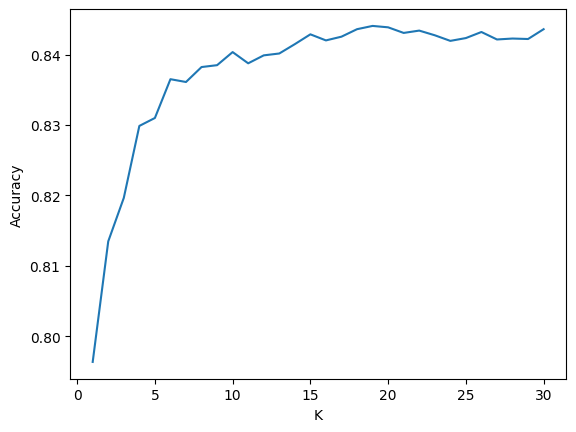

In [18]:
plt.plot(k_values, accuracies)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()